/tmp/ipykernel_4341/178230283.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


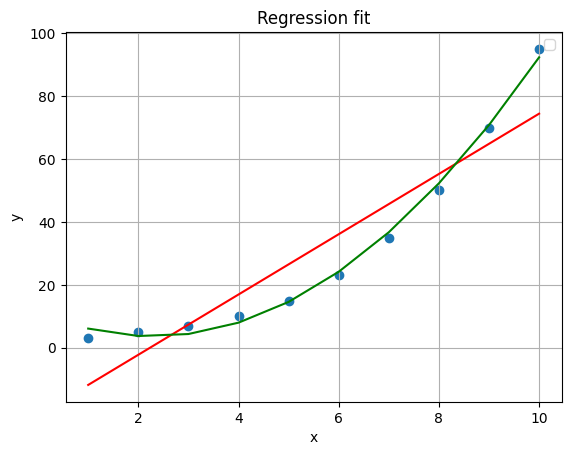

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

x = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([3,5,7,10,15,23,35,50,70,95])

model = LinearRegression()
model.fit(x,y)


polynomial_model = make_pipeline(PolynomialFeatures(degree=2),LinearRegression())
polynomial_model.fit(x,y)
polynomial_predictions = polynomial_model.predict(x)
m = model.coef_
b = model.intercept_
y_pred = m*x + b


plt.scatter(x,y)
plt.plot(x,y_pred,color = "red")
plt.plot(x,polynomial_predictions,color = "green")

plt.title("Regression fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import numpy as np

x1 = np.array([1,2,3,4,5,6,7,8,9,10])
x2 = np.array([40,45,50,55,60,65,70,75,80,85])
y = np.array([35,40,45,50,55,58,65,72,84,92])

x1.shape,x2.shape,y.shape

((10,), (10,), (10,))

In [16]:
X = np.column_stack([x1,x2])
X.shape
model = LinearRegression()
model.fit(X,y)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
m = model.coef_
b = model.intercept_
m,b

(array([0.85185185, 0.96296296]), np.float64(-6.037037037037003))

In [18]:
model.predict(X),y

(array([33.33333333, 39.        , 44.66666667, 50.33333333, 56.        ,
        61.66666667, 67.33333333, 73.        , 78.66666667, 92.        ]),
 array([35, 40, 45, 50, 55, 58, 65, 72, 84, 92]))

In [19]:
x1_grid, x2_grid = np.meshgrid(x1,x2)
y_grid = model.predict(np.column_stack([x1_grid.ravel(),x2_grid.ravel()]))
y_grid = y_grid.reshape(x1_grid.shape)
y_grid
#x1_grid, x2_grid
#np.column_stack([x1_grid,x2_grid]).shape

array([[33.33333333, 34.18518519, 35.03703704, 35.88888889, 36.74074074,
        37.59259259, 38.44444444, 39.2962963 , 40.14814815, 48.66666667],
       [38.14814815, 39.        , 39.85185185, 40.7037037 , 41.55555556,
        42.40740741, 43.25925926, 44.11111111, 44.96296296, 53.48148148],
       [42.96296296, 43.81481481, 44.66666667, 45.51851852, 46.37037037,
        47.22222222, 48.07407407, 48.92592593, 49.77777778, 58.2962963 ],
       [47.77777778, 48.62962963, 49.48148148, 50.33333333, 51.18518519,
        52.03703704, 52.88888889, 53.74074074, 54.59259259, 63.11111111],
       [52.59259259, 53.44444444, 54.2962963 , 55.14814815, 56.        ,
        56.85185185, 57.7037037 , 58.55555556, 59.40740741, 67.92592593],
       [57.40740741, 58.25925926, 59.11111111, 59.96296296, 60.81481481,
        61.66666667, 62.51851852, 63.37037037, 64.22222222, 72.74074074],
       [62.22222222, 63.07407407, 63.92592593, 64.77777778, 65.62962963,
        66.48148148, 67.33333333, 68.18518519

In [21]:
x1_grid.shape,x2_grid.shape,y_grid.shape

((10, 10), (10, 10), (10, 10))

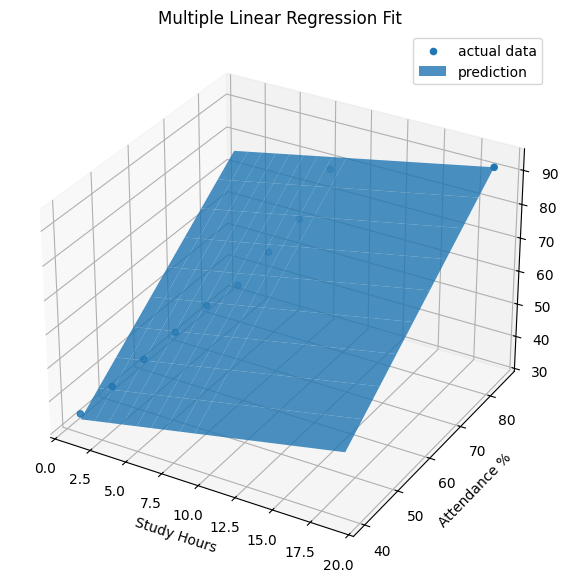

In [28]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(x1,x2,y,label ="actual data")
ax.plot_surface(x1_grid,x2_grid,y_grid,alpha =0.8, label="prediction")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Attendance %")
ax.set_zlabel("Marks")
plt.title("Multiple Linear Regression Fit")
ax.legend()
plt.show()       #z=w1*x1 + w2*x2 + b, m1*x1+m2*x2 + b


In [30]:
import plotly.graph_objects as go
fig = go.Figure()

In [36]:
fig.add_trace(go.Scatter3d(x=x1, y=x2, z=y, mode="markers", marker=dict(size=6), name="Actual Data"))
fig.add_trace(go.Surface(x=x1_grid, y=x2_grid, z=y_grid, opacity=0.8, name="Regression Plane"))
fig.update_layout(title="Multiple linear Regression", scene=dict(xaxis_title= "Study Hours", yaxis_title="attendance %",zaxis_title="Exam Score"),)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'type': 'scatter3d',
              'x': {'bdata': 'AQIDBAUGBwgJEw==', 'dtype': 'i1'},
              'y': {'bdata': 'KC0yNzxBRktQVQ==', 'dtype': 'i1'},
              'z': {'bdata': 'IygtMjc6QUhUXA==', 'dtype': 'i1'}},
             {'opacity': 0.8,
              'type': 'surface',
              'x': {'bdata': ('AQIDBAUGBwgJEwECAwQFBgcICRMBAg' ... 'MBAgMEBQYHCAkTAQIDBAUGBwgJEw=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'y': {'bdata': ('KCgoKCgoKCgoKC0tLS0tLS0tLS0yMj' ... 'tQUFBQUFBQUFBQVVVVVVVVVVVVVQ=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'z': {'bdata': ('rKqqqqqqQEB8Ce0ltBdBQE1oL6G9hE' ... 'LaS6hUQOwltJfQ3lRAAAAAAAAAV0A='),
                    'dtype': 'f8',
                    'shape': '10, 10'}},
             {'type': 'scatter3d',
              'x': {'bdata': 'AQIDBAUGBwgJEw==', 'dtype': 'i1'},
              'y': {'bdata': 'KC0yNzxBRktQVQ==', 'dtype': 'i1'},
              'z': {'bdata': 'IygtMjc6QUhUXA==', 'dtype': 'i1'}},
             {'opacity': 0.8,
              'type': 'surface',
              'x': {'bdata': ('AQIDBAUGBwgJEwECAwQFBgcICRMBAg' ... 'MBAgMEBQYHCAkTAQIDBAUGBwgJEw=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'y': {'bdata': ('KCgoKCgoKCgoKC0tLS0tLS0tLS0yMj' ... 'tQUFBQUFBQUFBQVVVVVVVVVVVVVQ=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'z': {'bdata': ('rKqqqqqqQEB8Ce0ltBdBQE1oL6G9hE' ... 'LaS6hUQOwltJfQ3lRAAAAAAAAAV0A='),
                    'dtype': 'f8',
                    'shape': '10, 10'}},
             {'type': 'scatter3d',
              'x': {'bdata': 'AQIDBAUGBwgJEw==', 'dtype': 'i1'},
              'y': {'bdata': 'KC0yNzxBRktQVQ==', 'dtype': 'i1'},
              'z': {'bdata': 'IygtMjc6QUhUXA==', 'dtype': 'i1'}},
             {'opacity': 0.8,
              'type': 'surface',
              'x': {'bdata': ('AQIDBAUGBwgJEwECAwQFBgcICRMBAg' ... 'MBAgMEBQYHCAkTAQIDBAUGBwgJEw=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'y': {'bdata': ('KCgoKCgoKCgoKC0tLS0tLS0tLS0yMj' ... 'tQUFBQUFBQUFBQVVVVVVVVVVVVVQ=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'z': {'bdata': ('rKqqqqqqQEB8Ce0ltBdBQE1oL6G9hE' ... 'LaS6hUQOwltJfQ3lRAAAAAAAAAV0A='),
                    'dtype': 'f8',
                    'shape': '10, 10'}},
             {'marker': {'size': 6},
              'mode': 'markers',
              'name': 'Actual Data',
              'type': 'scatter3d',
              'x': {'bdata': 'AQIDBAUGBwgJEw==', 'dtype': 'i1'},
              'y': {'bdata': 'KC0yNzxBRktQVQ==', 'dtype': 'i1'},
              'z': {'bdata': 'IygtMjc6QUhUXA==', 'dtype': 'i1'}},
             {'name': 'Regression Plane',
              'opacity': 0.8,
              'type': 'surface',
              'x': {'bdata': ('AQIDBAUGBwgJEwECAwQFBgcICRMBAg' ... 'MBAgMEBQYHCAkTAQIDBAUGBwgJEw=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'y': {'bdata': ('KCgoKCgoKCgoKC0tLS0tLS0tLS0yMj' ... 'tQUFBQUFBQUFBQVVVVVVVVVVVVVQ=='),
                    'dtype': 'i1',
                    'shape': '10, 10'},
              'z': {'bdata': ('rKqqqqqqQEB8Ce0ltBdBQE1oL6G9hE' ... 'LaS6hUQOwltJfQ3lRAAAAAAAAAV0A='),
                    'dtype': 'f8',
                    'shape': '10, 10'}},
             {'marker': {'size': 6},
              'mode': 'markers',
              'name': 'Actual Data',
              'type': 'scatter3d',
              'x': {'bdata': 'AQIDBAUGBwgJEw==', 'dtype': 'i1'},
              'y': {'bdata': 'KC0yNzxBRktQVQ==', 'dtype': 'i1'},
              'z': {'bdata': 'IygtMjc6QUhUXA==', 'dtype': 'i1'}},
             {'name': 'Regression Plane',
              'opacity': 0.8,
              'type': 'surface',
              'x': {'bdata': ('AQIDBAUGBwgJEwECAwQFBgcICRMBAg' ... 'MBAgMEBQYHCAkTAQIDBAUGBwgJE

In [39]:
import numpy as np

def error_return(x,y):
    m_best, b_best =np.polyfit(x,y,1)
    print(m_best,b_best)
    y_hat = m_best*x + b_best
    error = y_hat -y
    print(error)
    absolute_error = np.abs(error)
    print(absolute_error)
    squared_error = np.square(error)
    mean_absolute_error = np.mean(absolute_error)
    mean_squared_error = np.mean(squared_error)/2
    return mean_absolute_error, mean_squared_error

In [40]:
x = np.array([1,2,3,4,5])
y = np.array([3000,3500,5000,5500,6500])
error_return(x,y)

900.0000000000002 2000.0000000000007
[-1.0000000e+02  3.0000000e+02 -3.0000000e+02  1.0000000e+02
  1.8189894e-12]
[1.0000000e+02 3.0000000e+02 3.0000000e+02 1.0000000e+02 1.8189894e-12]


(np.float64(160.00000000000037), np.float64(19999.999999999964))

In [41]:
def compute_cost(m,b,x,y):
    predictions = m*x + b
    errors = predictions -y
    J = np.mean(errors**2)/2
    return J
compute_cost(1,1,x,y)

np.float64(11854409.0)

In [42]:
m_values = np.arange(800,1000,10)
b_values = np.arange(1900,2500,10)

In [57]:
M,B = np.meshgrid(m_values, b_values)
J = np.zeros(M.shape)

In [58]:
J[0,0]=compute_cost(M[0,0],B[0,0],x,y)

In [59]:
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        J[i,j] = compute_cost(M[i,j],B[i,j],x,y)

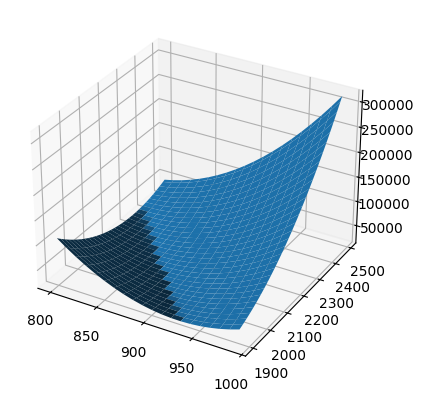

In [60]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(M,B,J)

In [66]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Surface(x = M, y = B, z = J)])
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
#Gradient and bnew